In [11]:
import pandas as pd    
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
import time

from scipy.special import beta as beta_func
import warnings
warnings.filterwarnings('ignore')

## Persiapan Parameter Optimasi

Menyusun parameter utama:
- $\mu$ : vektor expected return
- $e$ : vektor satuan
- $\Sigma$ : matriks kovarian
- $\Sigma^{-1}$ : invers kovarian

Parameter ini digunakan dalam proses optimasi portofolio.

In [12]:
df_selected = pd.read_csv("saham_terpilih.csv")
df_cov_matrix = pd.read_csv("covariance_matrix.csv", index_col=0)

In [13]:
mu = df_selected['Expected Return'].values.reshape(-1, 1)
e = np.ones((len(mu), 1))
sigma = df_cov_matrix.values
sigma_inv = np.linalg.inv(sigma)

In [14]:
print("mu:\n", mu)

mu:
 [[0.01926905]
 [0.01456736]
 [0.0117092 ]
 [0.01139947]
 [0.00757022]
 [0.00723104]
 [0.00654474]
 [0.00334539]
 [0.00305986]
 [0.00213708]]


In [15]:
print("\ne:\n", e)


e:
 [[1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]]


In [16]:
print("\nsigma:\n", sigma)


sigma:
 [[0.00206821 0.00143588 0.00047049 0.00029347 0.00052282 0.00015084
  0.00026162 0.00020305 0.00015687 0.00032004]
 [0.00143588 0.00206847 0.00052388 0.00029071 0.00048058 0.00020129
  0.0002918  0.00029218 0.00025633 0.00025291]
 [0.00047049 0.00052388 0.00124563 0.0003198  0.00050796 0.00015318
  0.00034201 0.00017345 0.00017394 0.00024286]
 [0.00029347 0.00029071 0.0003198  0.00120357 0.00034387 0.00021354
  0.00020972 0.00016617 0.00022486 0.0001702 ]
 [0.00052282 0.00048058 0.00050796 0.00034387 0.00117221 0.0002177
  0.00027461 0.00023026 0.00022121 0.00023277]
 [0.00015084 0.00020129 0.00015318 0.00021354 0.0002177  0.00047927
  0.0002001  0.00018373 0.00036185 0.00013155]
 [0.00026162 0.0002918  0.00034201 0.00020972 0.00027461 0.0002001
  0.00096719 0.00019305 0.00020436 0.00018049]
 [0.00020305 0.00029218 0.00017345 0.00016617 0.00023026 0.00018373
  0.00019305 0.00062976 0.00024061 0.00012171]
 [0.00015687 0.00025633 0.00017394 0.00022486 0.00022121 0.00036185
  0.0

In [17]:
print("\nsigma inverse:\n", sigma_inv)


sigma inverse:
 [[ 9.87773128e+02 -6.41557201e+02 -2.20424971e+01 -4.34567245e+01
  -1.57280499e+02 -4.63788440e+01 -2.38537624e+01  3.00945824e+01
   1.75917606e+02 -1.15102756e+02]
 [-6.41557201e+02  1.00726644e+03 -1.33067791e+02  3.97660819e+00
  -9.42443661e+00  5.26038003e+01 -2.05155419e+01 -1.49954937e+02
  -2.27320836e+02  3.27002095e+01]
 [-2.20424971e+01 -1.33067791e+02  1.09974436e+03 -1.17340963e+02
  -3.11294812e+02  4.20433874e+01 -2.13896308e+02 -8.77016474e+00
  -2.69961717e+01 -8.73152226e+01]
 [-4.34567245e+01  3.97660819e+00 -1.17340963e+02  9.87105066e+02
  -1.36282051e+02 -1.67007241e+02 -4.14332933e+01 -3.72834461e+01
  -1.60171545e+02 -3.22891493e+01]
 [-1.57280499e+02 -9.42443661e+00 -3.11294812e+02 -1.36282051e+02
   1.20478353e+03 -1.96159069e+02 -6.43755673e+01 -1.58296384e+02
  -4.43916315e+01 -5.95683319e+01]
 [-4.63788440e+01  5.26038003e+01  4.20433874e+01 -1.67007241e+02
  -1.96159069e+02  4.59464255e+03 -2.38183120e+02 -3.12031274e+01
  -2.98031266e+0

### Parameter PSO

Inisialisasi parameter Particle Swarm Optimization:
- 100 partikel, maksimal 1000 iterasi
- $w_{inertia}$= 0.75, c_1 = c_2 = 2

Menyiapkan e dan invers kovariansi.

In [18]:
num_particles = 100
num_iterations = 1000
w_inertia = 0.75
c1 = 2
c2 = 2

n = len(mu)  # jumlah saham
e = np.ones((n, 1))
sigma_inv = np.linalg.inv(sigma)

### Fungsi Objektif Mean-Variance

Fungsi yang dimaksimalkan:

$\max \quad 2t \cdot \mu^T w - \frac{1}{t} \cdot w^T \Sigma w - \lambda(\mathbf{e}^T\mathbf{w} - 1)^2$

- **$t$** = risk tolerance, **$1/t$** = risk aversion
- **$\lambda$** = penalti agar $\sum w_i = 1$

In [19]:
def objective_function(w, t, lamda):
    term1 = 2 * t * np.dot(mu.T, w)         
    term2 = (1/t) * np.dot(w.T, np.dot(sigma, w))
    term3 = lamda * (np.dot(e.T, w) - 1)**2    # penalti =1
    return float(term1 - term2 - term3)         

### Optimisasi PSO
Loop tiap nilai t:
- Hitung lambda dari solusi analitik Lagrangian
- Inisialisasi partikel dengan Dirichlet
- Update kecepatan dan posisi, normalisasi bobot
- Update personal best dan global best, berhenti jika konvergen
- Hitung expected return, variance, dan rasio portofolio

In [ ]:
stock_names = df_selected['Saham'].tolist()
iteration_results = []
iteration_results_exc = []  # tiap iterasi

start_time = time.time()

for t in np.arange(0.001, 0.5, 0.01):

    a     = float(np.dot(e.T, np.dot(sigma_inv, e)))
    b_num = 2*t * float(np.dot(e.T, np.dot(sigma_inv, mu))) + \
            2*t * float(np.dot(mu.T, np.dot(sigma_inv, e)))
    c_num = (2*t)**2 * float(np.dot(mu.T, np.dot(sigma_inv, mu))) - (4/t)*a
    disc  = b_num**2 - 4*a*c_num
    lamda = (-b_num + np.sqrt(disc)) / (2*a) if disc >= 0 else 1.0

    np.random.seed(int(t * 100))
    w_particles = np.random.dirichlet(np.ones(n), size=num_particles)
    v_particles = np.random.uniform(-1, 1, (num_particles, n))
    personal_best_positions = w_particles.copy()
    personal_best_scores = np.array([
        objective_function(w, t, lamda) for w in w_particles
    ])
    global_best_position = personal_best_positions[np.argmax(personal_best_scores)]
    global_best_score    = np.max(personal_best_scores)
    previous_global_best_score = -np.inf

    for iteration in range(num_iterations):
        np.random.seed(int(t * 100) + iteration)
        r1, r2 = np.random.rand(2)

        v_particles  = (w_inertia * v_particles
                        + c1 * r1 * (personal_best_positions - w_particles)
                        + c2 * r2 * (global_best_position   - w_particles))
        w_particles  = np.clip(w_particles + v_particles, 0, 1)
        w_particles /= np.sum(w_particles, axis=1, keepdims=True)

        scores = np.array([objective_function(w, t, lamda) for w in w_particles])
        better_mask = scores > personal_best_scores
        personal_best_scores[better_mask]    = scores[better_mask]
        personal_best_positions[better_mask] = w_particles[better_mask]

        if np.max(personal_best_scores) > global_best_score:
            previous_global_best_score = global_best_score
            global_best_score          = np.max(personal_best_scores)
            global_best_position       = personal_best_positions[np.argmax(personal_best_scores)]

        # Simpan tiap iterasi untuk Tabel 4.8
        w_exc     = global_best_position.reshape(-1, 1)
        mupt_exc  = float(np.dot(mu.T, w_exc))
        varpt_exc = float(np.dot(w_exc.T, np.dot(sigma, w_exc)))
        sig_exc   = np.sqrt(varpt_exc)
        rasio_exc = mupt_exc / sig_exc if sig_exc != 0 else 0

        iteration_results_exc.append(
            [t, iteration, lamda, global_best_score]
            + list(global_best_position)
            + [mupt_exc, sig_exc, varpt_exc, rasio_exc]
        )

        if abs(global_best_score - previous_global_best_score) < 1e-16:
            break

    # Simpan hanya iterasi terakhir untuk Tabel 4.9 & grafik
    w_best  = global_best_position.reshape(-1, 1)
    mupt    = float(np.dot(mu.T, w_best))
    varpt   = float(np.dot(w_best.T, np.dot(sigma, w_best)))
    sigmapt = np.sqrt(varpt)
    rasio   = mupt / sigmapt if sigmapt != 0 else 0

    iteration_results.append(
        [t, iteration, lamda, global_best_score]
        + list(global_best_position)
        + [mupt, sigmapt, varpt, rasio]
    )

columns = ["t", "Iteration", "Lambda", "Best Objective Value"] \
        + stock_names + ["mupt", "sigmapt", "varpt", "rasio"]

df_results     = pd.DataFrame(iteration_results,     columns=columns)
df_results_exc = pd.DataFrame(iteration_results_exc, columns=columns)

print(df_results)
print("Execution Time:", time.time() - start_time, "seconds")

        t  Iteration     Lambda  Best Objective Value      SCMA  EMTK  \
0   0.001        766  63.245541             -0.279677  0.025146   0.0   
1   0.011        223  19.069118             -0.025450  0.000000   0.0   
2   0.021        148  13.801055             -0.013277  0.040890   0.0   
3   0.031        334  11.358858             -0.008693  0.000000   0.0   
4   0.041        290   9.876796             -0.006309  0.038914   0.0   
5   0.051        170   8.855526             -0.004846  0.044876   0.0   
6   0.061        169   8.097019             -0.003792  0.050965   0.0   
7   0.071        161   7.505000             -0.002989  0.061373   0.0   
8   0.081        132   7.026295             -0.002340  0.071554   0.0   
9   0.091        199   6.628825             -0.001790  0.083141   0.0   
10  0.101        193   6.291935             -0.001305  0.096075   0.0   
11  0.111        195   6.001647             -0.000866  0.110357   0.0   
12  0.121        131   5.748119             -0.0004

In [28]:
df_results.to_csv("tabel49_pso_results.csv", index=False, float_format='%.5f')

In [ ]:

# Ambil t
t_show = 0.001
print(f"Menampilkan iterasi PSO untuk t = {t_show:.4f}\n")

df_tabel48 = df_results_exc[
    np.isclose(df_results_exc['t'], t_show, atol=1e-6)
].copy().reset_index(drop=True)

df_tabel48.index.name = 'Iterasi'

# Kolom yang ditampilkan: Lambda, f(x), bobot saham, mupt, sigmapt, varpt, rasio
cols_show = ['Lambda', 'Best Objective Value'] + stock_names + ['mupt', 'sigmapt', 'varpt', 'rasio']

pd.options.display.float_format = '{:.6f}'.format
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)

print(df_tabel48[cols_show])
print(f"\nTotal iterasi konvergen: {len(df_tabel48)}")
df_tabel48.to_csv("table48_pso_iterations.csv", index=False)

Menampilkan iterasi PSO untuk t = 0.0010

           Lambda  Best Objective Value     SCMA     EMTK     NCKL     UNVR     INKP     BBRI     MAPI     TLKM     BMRI     AADI     mupt  sigmapt    varpt    rasio
Iterasi                                                                                                                                                              
0       63.245541             -0.294866 0.000000 0.000000 0.018583 0.038216 0.067758 0.246857 0.183042 0.137085 0.197584 0.110875 0.005449 0.017172 0.000295 0.317337
1       63.245541             -0.293908 0.025223 0.000000 0.000000 0.000000 0.082632 0.232218 0.168089 0.217357 0.135373 0.139109 0.005329 0.017144 0.000294 0.310865
2       63.245541             -0.291204 0.054791 0.000000 0.000000 0.037658 0.064887 0.335830 0.138172 0.203615 0.090173 0.074873 0.006426 0.017065 0.000291 0.376563
3       63.245541             -0.286313 0.056967 0.000000 0.000000 0.049263 0.048001 0.297642 0.128568 0.207394 0.105329 0.10683

### Visualisasi
- Efficient frontier
- Kinerja portofolio
- Konvergensi PSO

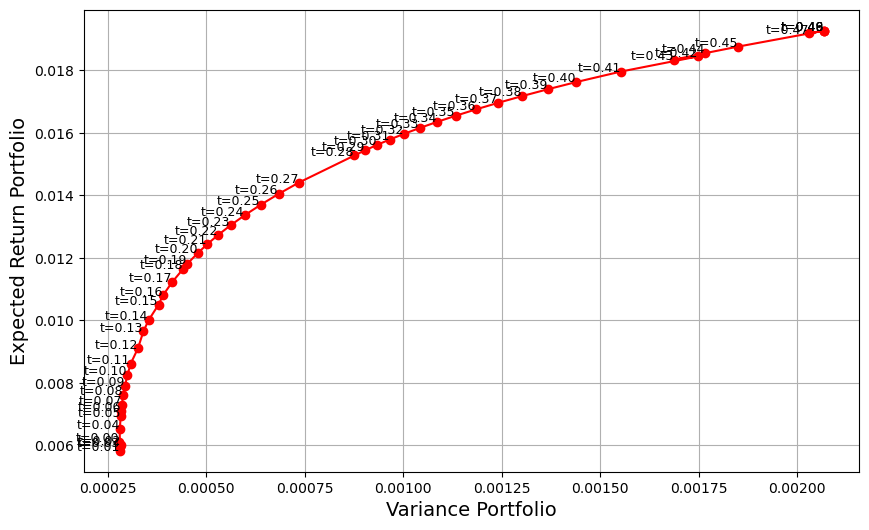

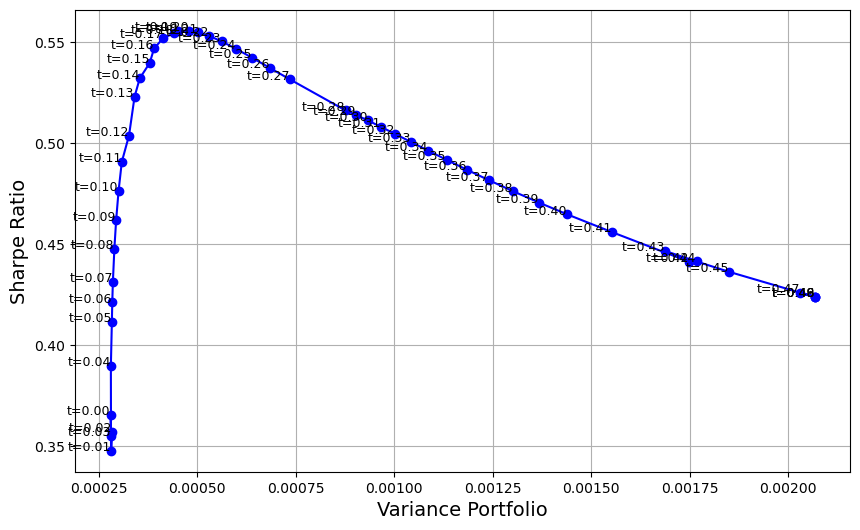

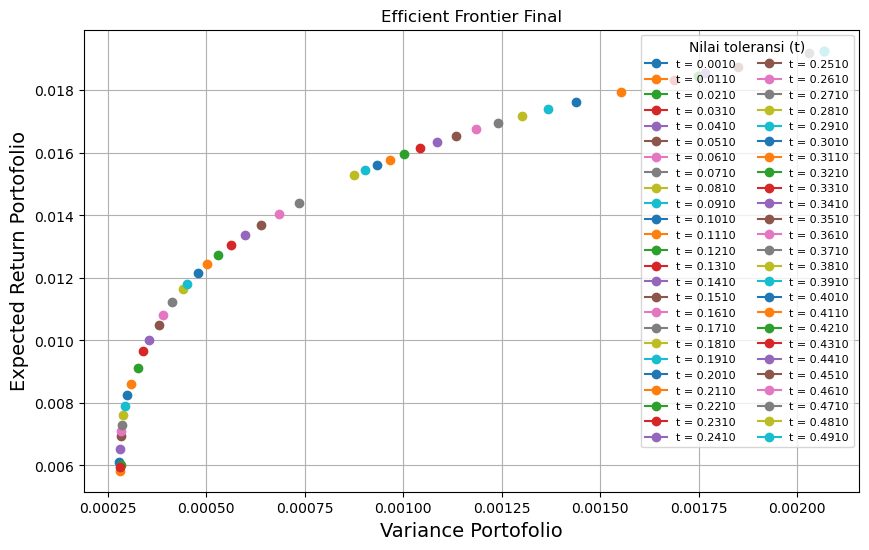

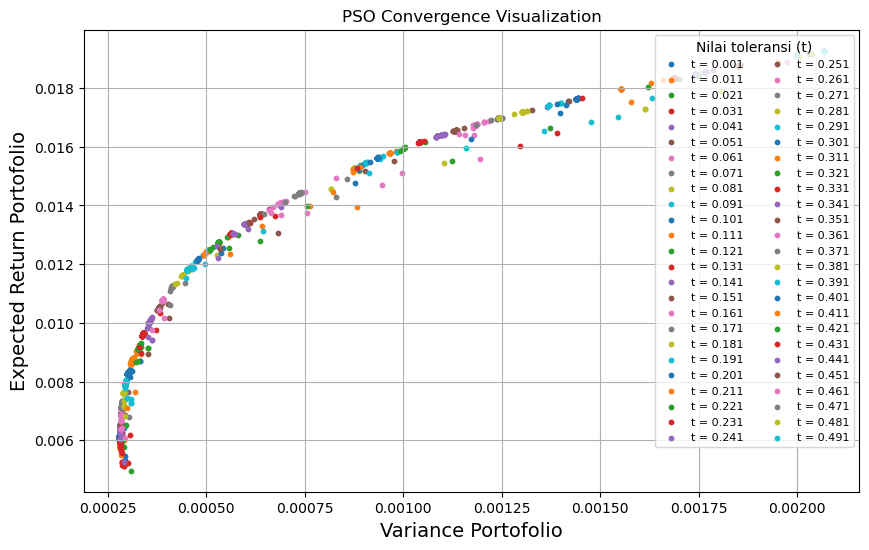

In [23]:
import matplotlib.pyplot as plt


# Ambil iterasi terakhir dari setiap nilai t
last_iteration_data = df_results.groupby('t').tail(1)

# Urutkan data berdasarkan nilai t
last_iteration_data = last_iteration_data.sort_values(by='t')

# 1. Plot Grafik Permukaan Portofolio Efisien
plt.figure(figsize=(10, 6))
plt.plot(last_iteration_data['varpt'], last_iteration_data['mupt'], marker="o", color='red', linestyle='-', label='t values')

for i, row in last_iteration_data.iterrows():
    plt.text(row['varpt'], row['mupt'], f"t={row['t']:.2f}", fontsize=9, ha='right')

plt.xlabel('Variance Portfolio', fontsize=14)
plt.ylabel('Expected Return Portfolio', fontsize=14)
plt.grid(True)
plt.show()

# 2. Plot Grafik Kinerja Portofolio

plt.figure(figsize=(10, 6))
plt.plot(last_iteration_data['varpt'], last_iteration_data['rasio'], marker="o", color='blue', linestyle='-', label='t values')

for i, row in last_iteration_data.iterrows():
    plt.text(row['varpt'], row['rasio'], f"t={row['t']:.2f}", fontsize=9, ha='right')

plt.xlabel('Variance Portfolio', fontsize=14)
plt.ylabel('Sharpe Ratio', fontsize=14)
plt.grid(True)
plt.show()

# Plot Hasil Akhir Portofolio Optimal
plt.figure(figsize=(10, 6))

for i, t_value in enumerate(df_results['t'].unique()):
    t_data = df_results[df_results['t'] == t_value]
    plt.plot(t_data['varpt'], t_data['mupt'], marker='o', linestyle='-', label=f't = {t_value:.4f}')
plt.title("Efficient Frontier Final")
plt.xlabel('Variance Portofolio', fontsize=14)
plt.ylabel('Expected Return Portofolio', fontsize=14)
plt.legend(title="Nilai toleransi (t)", fontsize=8, loc='upper right', ncol=2)
plt.grid(True)
plt.show()

# Visualisasi Iterasi Untuk Setiap Nilai t
plt.figure(figsize=(10, 6))

for t_value in df_results_exc['t'].unique():
    t_data = df_results_exc[df_results_exc['t'] == t_value]
    plt.scatter(t_data['varpt'], t_data['mupt'], 
                s=10, label=f't = {t_value:.3f}')
plt.title("PSO Convergence Visualization")
plt.xlabel('Variance Portofolio', fontsize=14)
plt.ylabel('Expected Return Portofolio', fontsize=14)
plt.legend(title="Nilai toleransi (t)", fontsize=8, loc='upper right', ncol=2)
plt.grid(True)
plt.show()

In [ ]:

num_trials = 50
global_best_scores = []
mu_pt = []
sigma_pt = []
var_pt = []
rasio_pt = []
iterasi_pt = []
execution_times = []

t_optimal = df_results.loc[df_results['rasio'].idxmax(), 't']
print(f"t optimal: {t_optimal:.4f}\n")

for trial in range(num_trials):
    start_time = time.time()

    # Hitung lambda
    a = float(np.dot(e.T, np.dot(sigma_inv, e)))
    b_num = 2 * t_optimal * float(np.dot(e.T, np.dot(sigma_inv, mu))) + \
            2 * t_optimal * float(np.dot(mu.T, np.dot(sigma_inv, e)))
    c_num = (2 * t_optimal)**2 * float(np.dot(mu.T, np.dot(sigma_inv, mu))) - (4 / t_optimal) * a
    discriminant = b_num**2 - 4 * a * c_num
    lamda = (-b_num + np.sqrt(discriminant)) / (2 * a) if discriminant >= 0 else 1.0

    # Inisialisasi PSO — tanpa seed (acak murni)
    w_particles = np.random.dirichlet(np.ones(n), size=num_particles)
    v_particles = np.random.uniform(-1, 1, (num_particles, n))
    personal_best_positions = w_particles.copy()
    personal_best_scores = np.array([
        objective_function(w, t_optimal, lamda) for w in w_particles
    ])
    global_best_position = personal_best_positions[np.argmax(personal_best_scores)]
    global_best_score = np.max(personal_best_scores)
    previous_global_best_score = -np.inf
    last_iter = 0

    for iteration in range(num_iterations):
        r1, r2 = np.random.rand(2)
        v_particles = (w_inertia * v_particles +
                       c1 * r1 * (personal_best_positions - w_particles) +
                       c2 * r2 * (global_best_position - w_particles))
        w_particles = w_particles + v_particles
        w_particles = np.clip(w_particles, 0, 1)
        w_particles /= np.sum(w_particles, axis=1, keepdims=True)

        scores = np.array([objective_function(w, t_optimal, lamda) for w in w_particles])
        better_mask = scores > personal_best_scores
        personal_best_scores[better_mask] = scores[better_mask]
        personal_best_positions[better_mask] = w_particles[better_mask]

        if np.max(personal_best_scores) > global_best_score:
            previous_global_best_score = global_best_score
            global_best_score = np.max(personal_best_scores)
            global_best_position = personal_best_positions[np.argmax(personal_best_scores)]

        last_iter = iteration + 1
        if abs(global_best_score - previous_global_best_score) < 1e-16:
            break

    w_best = global_best_position.reshape(-1, 1)
    mupt_   = float(np.dot(mu.T, w_best))
    varpt_  = float(np.dot(w_best.T, np.dot(sigma, w_best)))
    sigmapt_ = np.sqrt(varpt_)
    rasio_  = mupt_ / sigmapt_ if sigmapt_ != 0 else 0  # Sharpe ratio = mupt/sigmapt

    global_best_scores.append(global_best_score)
    mu_pt.append(mupt_)
    sigma_pt.append(sigmapt_)
    var_pt.append(varpt_)
    rasio_pt.append(rasio_)
    iterasi_pt.append(last_iter)
    execution_times.append(time.time() - start_time)

# Output Tabel 4.10
results_df = pd.DataFrame({
    'Percobaan': range(1, num_trials + 1),
    'Iterasi': iterasi_pt,
    'mupt': mu_pt,
    'sigmapt': sigma_pt,
    'varpt': var_pt,
    'Sharpe Ratio': rasio_pt,
    'Waktu (s)': execution_times
})

pd.options.display.float_format = '{:.10f}'.format
print(results_df.to_string(index=False))
print(f"\nRata-rata  : mupt={np.mean(mu_pt):.10f}, sigmapt={np.mean(sigma_pt):.10f}, varpt={np.mean(var_pt):.10f}, rasio={np.mean(rasio_pt):.10f}, waktu={np.mean(execution_times):.2f}s")
print(f"Std. Deviasi: mupt={np.std(mu_pt):.2e}, sigmapt={np.std(sigma_pt):.2e}, varpt={np.std(var_pt):.2e}, rasio={np.std(rasio_pt):.2e}")

t optimal: 0.2010

 Percobaan  Iterasi         mupt      sigmapt        varpt  Sharpe Ratio    Waktu (s)
         1      151 0.0121612558 0.0218907753 0.0004792060  0.5555424877 0.4837491512
         2      106 0.0121612544 0.0218907729 0.0004792059  0.5555424892 0.3194956779
         3      203 0.0121612580 0.0218907794 0.0004792062  0.5555424851 0.6078045368
         4      212 0.0121612558 0.0218907753 0.0004792060  0.5555424877 0.6494774818
         5      153 0.0121612529 0.0218907699 0.0004792058  0.5555424910 0.4865539074
         6      215 0.0121612562 0.0218907762 0.0004792061  0.5555424871 0.6342878342
         7      200 0.0121276801 0.0218266046 0.0004764007  0.5556375061 0.6538512707
         8      141 0.0121612582 0.0218907799 0.0004792062  0.5555424848 0.4057493210
         9      294 0.0121276728 0.0218265910 0.0004764001  0.5556375157 0.9355084896
        10      248 0.0121612554 0.0218907747 0.0004792060  0.5555424881 0.8215513229
        11      115 0.0121612534 0.

In [ ]:
results_df['mupt'] = results_df['mupt'].round(10)
results_df['sigmapt'] = results_df['sigmapt'].round(10)
results_df['varpt'] = results_df['varpt'].round(10)
results_df['Sharpe Ratio'] = results_df['Sharpe Ratio'].round(10)
results_df['Waktu (s)'] = results_df['Waktu (s)'].round(2)

# Simpan
results_df.to_csv("tabel4.10_trials.csv", index=False)
print("Saved: tabel4.10_trials.csv")

# Tampilkan dengan format rapi
print("\nTabel 4.10 Hasil Uji Coba Algoritma PSO (50 Percobaan)")
print("="*80)
print(results_df.to_string(index=False))

Saved: tabel4.10_trials.csv

Tabel 4.10 Hasil Uji Coba Algoritma PSO (50 Percobaan)
 Percobaan  Iterasi         mupt      sigmapt        varpt  Sharpe Ratio    Waktu (s)
         1      151 0.0121612558 0.0218907753 0.0004792060  0.5555424877 0.4800000000
         2      106 0.0121612544 0.0218907729 0.0004792059  0.5555424892 0.3200000000
         3      203 0.0121612580 0.0218907794 0.0004792062  0.5555424851 0.6100000000
         4      212 0.0121612558 0.0218907753 0.0004792060  0.5555424877 0.6500000000
         5      153 0.0121612529 0.0218907699 0.0004792058  0.5555424910 0.4900000000
         6      215 0.0121612562 0.0218907762 0.0004792061  0.5555424871 0.6300000000
         7      200 0.0121276801 0.0218266046 0.0004764007  0.5556375061 0.6500000000
         8      141 0.0121612582 0.0218907799 0.0004792062  0.5555424848 0.4100000000
         9      294 0.0121276728 0.0218265910 0.0004764001  0.5556375157 0.9400000000
        10      248 0.0121612554 0.0218907747 0.00047920

In [ ]:
param_combinations = [
    {'w': 0.1,  'c1': 2,   'c2': 2,   'label': 'w=0.1, c1=2, c2=2'},
    {'w': 0.25, 'c1': 0.1, 'c2': 0.1, 'label': 'w=0.25, c1=0.1, c2=0.1'},
    {'w': 0.75, 'c1': 2,   'c2': 2,   'label': 'w=0.75, c1=2, c2=2'},   # parameter utama
    {'w': 0.75, 'c1': 0.1, 'c2': 0.1, 'label': 'w=0.75, c1=0.1, c2=0.1'},
    {'w': 1.0,  'c1': 2,   'c2': 2,   'label': 'w=1, c1=2, c2=2'},
]
n_repeat = 5

param_results = []

for params in param_combinations:
    for rep in range(n_repeat):

        # Hitung lambda pakai t_optimal
        a = float(np.dot(e.T, np.dot(sigma_inv, e)))
        b_num = 2 * t_optimal * float(np.dot(e.T, np.dot(sigma_inv, mu))) + \
                2 * t_optimal * float(np.dot(mu.T, np.dot(sigma_inv, e)))
        c_num = (2 * t_optimal)**2 * float(np.dot(mu.T, np.dot(sigma_inv, mu))) - (4 / t_optimal) * a
        discriminant = b_num**2 - 4 * a * c_num
        lamda = (-b_num + np.sqrt(discriminant)) / (2 * a) if discriminant >= 0 else 1.0

        # Inisialisasi PSO dengan parameter variasi
        w_particles = np.random.dirichlet(np.ones(n), size=num_particles)
        v_particles = np.random.uniform(-1, 1, (num_particles, n))
        personal_best_positions = w_particles.copy()
        personal_best_scores = np.array([
            objective_function(w, t_optimal, lamda) for w in w_particles
        ])
        global_best_position = personal_best_positions[np.argmax(personal_best_scores)]
        global_best_score = np.max(personal_best_scores)
        previous_global_best_score = -np.inf
        last_iter = 0

        for iteration in range(num_iterations):
            r1, r2 = np.random.rand(2)
            v_particles = (params['w'] * v_particles +
                           params['c1'] * r1 * (personal_best_positions - w_particles) +
                           params['c2'] * r2 * (global_best_position - w_particles))
            w_particles = w_particles + v_particles
            w_particles = np.clip(w_particles, 0, 1)
            w_particles /= np.sum(w_particles, axis=1, keepdims=True)

            scores = np.array([objective_function(w, t_optimal, lamda) for w in w_particles])
            better_mask = scores > personal_best_scores
            personal_best_scores[better_mask] = scores[better_mask]
            personal_best_positions[better_mask] = w_particles[better_mask]

            if np.max(personal_best_scores) > global_best_score:
                previous_global_best_score = global_best_score
                global_best_score = np.max(personal_best_scores)
                global_best_position = personal_best_positions[np.argmax(personal_best_scores)]

            last_iter = iteration + 1
            if abs(global_best_score - previous_global_best_score) < 1e-16:
                break

        w_best = global_best_position.reshape(-1, 1)
        rasio_ = float(np.dot(mu.T, w_best)) / np.sqrt(float(np.dot(w_best.T, np.dot(sigma, w_best))))

        row = {
            'Parameter': params['label'],
            'Iterasi': last_iter,
            'Rasio': rasio_
        }
        for idx, sn in enumerate(stock_names):
            row[sn] = round(global_best_position[idx], 5)

        param_results.append(row)

df_param_test = pd.DataFrame(param_results)
cols = ['Parameter', 'Iterasi'] + stock_names + ['Rasio']
print(df_param_test[cols].to_string(index=False))

df_param_test[cols].to_csv("tabel411_parameter_test.csv", index=False)

             Parameter  Iterasi         SCMA         EMTK         NCKL         UNVR         INKP         BBRI         MAPI         TLKM         BMRI         AADI        Rasio
     w=0.1, c1=2, c2=2       40 0.2205300000 0.0150600000 0.2075000000 0.2250500000 0.0000000000 0.3196200000 0.0109300000 0.0000000000 0.0000000000 0.0013000000 0.5514757530
     w=0.1, c1=2, c2=2       32 0.2784500000 0.0000000000 0.1684500000 0.1966000000 0.0000000000 0.2608300000 0.0833700000 0.0000000000 0.0122900000 0.0000000000 0.5503302135
     w=0.1, c1=2, c2=2       37 0.2659900000 0.0000000000 0.1669400000 0.1848200000 0.0000000000 0.3185100000 0.0568100000 0.0000000000 0.0000000000 0.0069200000 0.5536065530
     w=0.1, c1=2, c2=2       39 0.2918700000 0.0000000000 0.1598800000 0.2213600000 0.0018300000 0.2462900000 0.0462900000 0.0000000000 0.0324800000 0.0000000000 0.5479858181
     w=0.1, c1=2, c2=2       33 0.2779200000 0.0000000000 0.1710000000 0.1965100000 0.0000000000 0.3545700000 0.0000000000 0.

In [ ]:
def run_pso_custom(mu_input, sigma_input, t_val, n_particles=100, n_iter=1000,
                   w=0.75, c1=2, c2=2):
    
    n_saham = len(mu_input)
    e_custom = np.ones((n_saham, 1))
    sigma_inv_custom = np.linalg.inv(sigma_input)

    def obj(ww, t, lam):
        term1 = 2 * t * np.dot(mu_input.T, ww)
        term2 = (1/t) * np.dot(ww.T, np.dot(sigma_input, ww))
        term3 = lam * (np.dot(e_custom.T, ww) - 1)**2
        return float(term1 - term2 - term3)

    # Hitung lambda
    a   = float(np.dot(e_custom.T, np.dot(sigma_inv_custom, e_custom)))
    b_n = 2*t_val * float(np.dot(e_custom.T, np.dot(sigma_inv_custom, mu_input))) + \
          2*t_val * float(np.dot(mu_input.T, np.dot(sigma_inv_custom, e_custom)))
    c_n = (2*t_val)**2 * float(np.dot(mu_input.T, np.dot(sigma_inv_custom, mu_input))) - (4/t_val)*a
    disc = b_n**2 - 4*a*c_n
    lam  = (-b_n + np.sqrt(abs(disc))) / (2*a)

    wp = np.random.dirichlet(np.ones(n_saham), size=n_particles)
    vp = np.random.uniform(-1, 1, (n_particles, n_saham))
    pbp = wp.copy()
    pbs = np.array([obj(ww, t_val, lam) for ww in wp])
    gbp = pbp[np.argmax(pbs)]
    gbs = np.max(pbs)
    prev_gbs = -np.inf
    last_it = 0

    for it in range(n_iter):
        r1, r2 = np.random.rand(2)
        vp = w*vp + c1*r1*(pbp - wp) + c2*r2*(gbp - wp)
        wp = np.clip(wp + vp, 0, 1)
        wp /= np.sum(wp, axis=1, keepdims=True)
        sc = np.array([obj(ww, t_val, lam) for ww in wp])
        mask = sc > pbs
        pbs[mask] = sc[mask]
        pbp[mask] = wp[mask]
        if np.max(pbs) > gbs:
            prev_gbs = gbs
            gbs = np.max(pbs)
            gbp = pbp[np.argmax(pbs)]
        last_it = it + 1
        if abs(gbs - prev_gbs) < 1e-16:
            break

    return gbp, last_it

# Hasil Algoritma PSO terhadap nilai random mu
print("Hasil Algoritma PSO terhadap nilai random mu")

np.random.seed(42)
mu_random = np.random.uniform(0.0001, 0.002, (n, 1))  # acak positif

t_values_uji = [0.001, 0.05, 0.10, 0.15, 0.20]
rows_412 = []

for tau in t_values_uji:
    t_use = max(tau, 0.001)  # hindari t=0 karena ada 1/t
    w_opt, it = run_pso_custom(mu_random, sigma, t_use)
    total = round(sum(w_opt), 4)
    row = {'τ': tau, 'Iterasi': it}
    for s, ww in zip(stock_names, w_opt):
        row[s] = round(ww, 4)
    row['Total'] = total
    rows_412.append(row)

df_412 = pd.DataFrame(rows_412)
pd.options.display.float_format = '{:.4f}'.format
print(df_412.to_string(index=False))

print("Hasil Algoritma PSO terhadap nilai modifikasi sigma")

sigma_diagonal = np.diag(np.diag(sigma))

rows_413 = []

for tau in t_values_uji:
    t_use = max(tau, 0.001)
    w_opt, it = run_pso_custom(mu, sigma_diagonal, t_use)
    total = round(sum(w_opt), 4)
    row = {'τ': tau, 'Iterasi': it}
    for s, ww in zip(stock_names, w_opt):
        row[s] = round(ww, 4)
    row['Total'] = total
    rows_413.append(row)

df_413 = pd.DataFrame(rows_413)
print(df_413.to_string(index=False))

df_412.to_csv("tabel412_random_mu.csv", index=False)

df_413.to_csv("tabel413_modified_sigma.csv", index=False)

Hasil Algoritma PSO terhadap nilai random mu
     τ  Iterasi   SCMA   EMTK   NCKL   UNVR   INKP   BBRI   MAPI   TLKM   BMRI   AADI  Total
0.0010      466 0.0274 0.0000 0.0655 0.0778 0.0000 0.3534 0.0972 0.2408 0.0000 0.1378 1.0000
0.0500      398 0.0271 0.0000 0.0650 0.0744 0.0000 0.2800 0.0912 0.2268 0.1013 0.1342 1.0000
0.1000      382 0.0239 0.0000 0.0664 0.0748 0.0101 0.2526 0.0819 0.2358 0.1178 0.1366 1.0000
0.1500      225 0.0223 0.0000 0.0759 0.0786 0.0000 0.2118 0.0680 0.2547 0.1464 0.1422 1.0000
0.2000      247 0.0000 0.0169 0.0853 0.0833 0.0000 0.1543 0.0482 0.2784 0.1821 0.1515 1.0000
Hasil Algoritma PSO terhadap nilai modifikasi sigma
     τ  Iterasi   SCMA   EMTK   NCKL   UNVR   INKP   BBRI   MAPI   TLKM   BMRI   AADI  Total
0.0010      595 0.0439 0.0438 0.0729 0.0754 0.0774 0.1894 0.0939 0.1442 0.1760 0.0830 1.0000
0.0500      605 0.0588 0.0531 0.0824 0.0846 0.0787 0.1908 0.0928 0.1298 0.1571 0.0720 1.0000
0.1000      654 0.1034 0.0806 0.1110 0.1123 0.0826 0.1949 0.0895 0